# Why the training data cannot train a model

**Question:** can the 20,000 historical tickets teach the triage agent how to fill the seven output fields (work type, service, team, assignee, priority, resolution status, resolution comment)?

**Short answer:** for three fields, yes, and they are trivial. For all the others, no: the values are statistically independent of everything else in the export. The charts below show it field by field. Each one is titled with its message and saved as a PNG in `figures/` (300-dpi-ready, for slides). Set `SAVE_FIGURES = False` in the setup cell to stop that.

| # | Chart | Message |
|---|---|---|
| 1 | Templates | 20,000 tickets are 11 texts times 20 service names |
| 2 | Signal vs noise | Only work type, service and team can be learned from the text |
| 3 | Priority | Priority does not follow urgency and impact |
| 4 | Resolution | The resolution status is a coin toss in every template |
| 5 | Resolution time | Uniform between 1 and 21 days, unrelated to anything |
| 6 | Assignee: fields | No field explains who becomes the assignee |
| 7 | Assignee: models | Every model is at chance level |

## Setup and data

In [10]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

SEED = 42
SAVE_FIGURES = True  # writes one PNG per chart into figures/ for the slides
FIG_DIR = Path("figures")

# One accent hue for the finding, one highlight, everything that is noise stays grey.
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#ffffff"
ACCENT, ACCENT_2, NOISE = "#2a78d6", "#eb6834", "#b9b8b0"
CATEGORICAL = [ACCENT, ACCENT_2, "#2f9e8f", "#8a6bd1", "#c9a227"]

plt.rcParams.update({
    "figure.figsize": (12, 6.5), "figure.dpi": 100, "savefig.dpi": 200,
    "font.size": 13, "axes.titlesize": 18, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 26,
    "axes.facecolor": SURFACE, "figure.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
})


def finish(fig, ax, name, subtitle):
    """Adds the subtitle under the title, saves the chart for the slides and shows it."""
    ax.annotate(subtitle, (0, 1), xycoords="axes fraction", xytext=(0, 8), textcoords="offset points",
                color=INK_2, fontsize=12.5, va="bottom")
    fig.tight_layout()
    if SAVE_FIGURES:
        FIG_DIR.mkdir(exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()


def finish_panels(fig, name, title, subtitle):
    """Same as finish() for figures with several panels: title and subtitle sit above all of them."""
    fig.suptitle(title, x=0.01, ha="left", fontsize=18, fontweight="bold", y=1.10)
    fig.text(0.01, 1.035, subtitle, color=INK_2, fontsize=12.5, ha="left", va="bottom")
    fig.tight_layout()
    if SAVE_FIGURES:
        FIG_DIR.mkdir(exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()


DATA_PATH = Path("jira_first_20000_requested_fields_synthetic.json")
with open(DATA_PATH, "r", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))

for col in ["Created date", "Resolution date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df["Comment count"] = df["All Comments"].apply(lambda x: len(x) if isinstance(x, list) else 0)
print(f"{len(df):,} tickets, {df.shape[1]} fields")

20,000 tickets, 17 fields


In [11]:
def first(values):
    # Every ticket has exactly one value per list field.
    return values[0] if isinstance(values, list) and values else "(none)"


def commenter(comments, position):
    return comments[position].split(":")[0] if isinstance(comments, list) and comments else "(none)"


t = pd.DataFrame(index=df.index)
t["Work type"] = df["Work type"]
t["Service"] = df["Affected Business or IT Services"].map(first)
t["Team"] = df["Service Team(s)"].map(first)
t["Business entity"] = df["Business Entity"].map(first)
t["Reporter"] = df["Reporter"]
t["Assignee"] = df["Assignee"]
for col in ["Priority", "Urgency", "Impact", "Status", "Resolution"]:
    t[col] = df[col]
t["Text"] = df["Summary"] + "\n" + df["Description"]

# The ticket texts are templates with a service name filled in. Removing the names shows the template.
names = sorted(t["Service"].unique(), key=len, reverse=True)
NAME_RE = re.compile("|".join(map(re.escape, names)))
t["Template"] = df["Description"].map(lambda d: NAME_RE.sub("<service>", d))
summary_pattern = df["Summary"].map(lambda s: NAME_RE.sub("<service>", s))
label_of = summary_pattern.groupby(t["Template"]).agg(lambda s: s.value_counts().index[0])
t["Template label"] = t["Template"].map(label_of)

LEVELS = {"lowest": 0, "low": 1, "medium": 2, "high": 3, "highest": 4}
LEVEL_NAMES = list(LEVELS)
resolution_days = (df["Resolution date"] - df["Created date"]).dt.total_seconds() / 86400

print(f"{t['Text'].nunique()} distinct texts, {t['Template'].nunique()} templates, {t['Service'].nunique()} services, "
      f"{t['Assignee'].nunique()} assignees, {t['Reporter'].nunique()} reporters")

173 distinct texts, 11 templates, 20 services, 30 assignees, 92 reporters


## 1 · 20,000 tickets are 11 texts times 20 service names

Every ticket text is one of 11 templates with a service name filled in: 173 distinct texts in total, however many tickets there are. The work type follows from the template with 100 % certainty (blue = incident, orange = service request).

Consequence: the "knowledge" in the data is a small lookup table, not 20,000 independent examples.

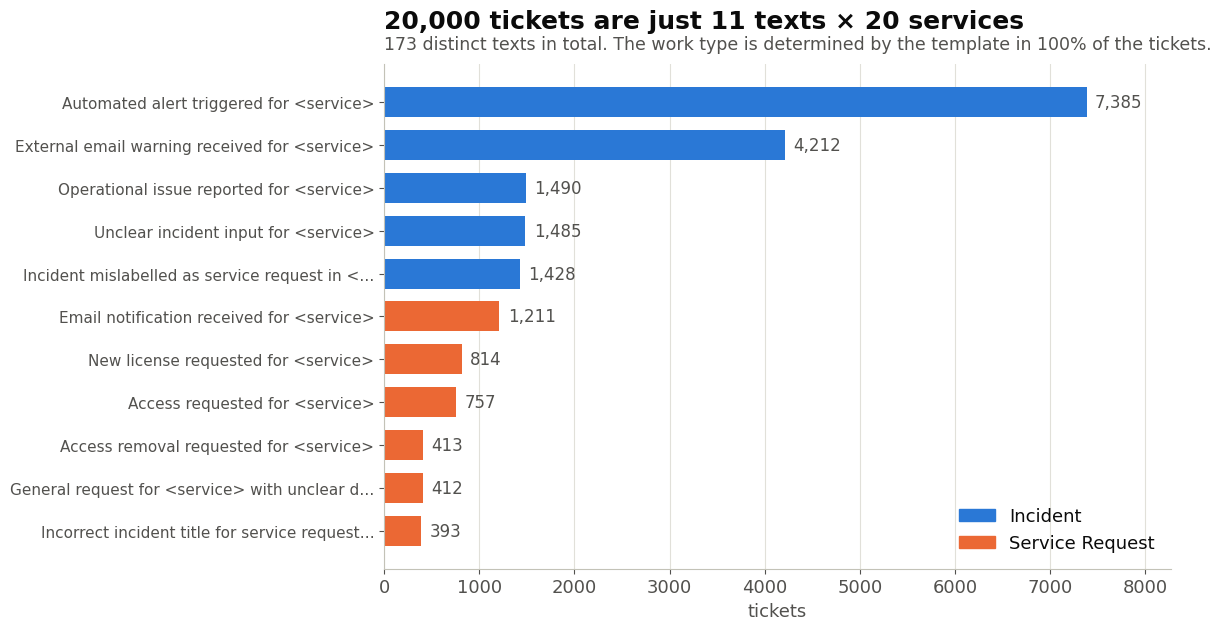

In [12]:
by_template = t.groupby("Template label").agg(tickets=("Text", "size"), work_type=("Work type", lambda s: s.value_counts().index[0]),
                                              purity=("Work type", lambda s: s.value_counts(normalize=True).iloc[0])).sort_values("tickets")
colors = [ACCENT if w == "Incident" else ACCENT_2 for w in by_template["work_type"]]

fig, ax = plt.subplots()
pos = np.arange(len(by_template))
ax.barh(pos, by_template["tickets"], height=0.7, color=colors)
for y, n in zip(pos, by_template["tickets"]):
    ax.annotate(f"{n:,}", (n, y), xytext=(6, 0), textcoords="offset points", va="center", color=INK_2, fontsize=12)
ax.set_yticks(pos, [l if len(l) <= 46 else l[:44] + "…" for l in by_template.index], fontsize=11)
ax.set_xlim(0, by_template["tickets"].max() * 1.12)
ax.set_xlabel("tickets")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_title("20,000 tickets are just 11 texts × 20 services")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=ACCENT), plt.Rectangle((0, 0), 1, 1, color=ACCENT_2)],
          labels=["Incident", "Service Request"], frameon=False, loc="lower right")
finish(fig, ax, "01_templates", f"{t['Text'].nunique()} distinct texts in total. The work type is determined by the template in "
       f"{(by_template['purity'] * by_template['tickets']).sum() / len(t):.0%} of the tickets.")

## 2 · Only work type, service and team can be learned from the text

For every field: how well can the **best possible** text-based predictor guess it on tickets it has not seen?

- The predictor is a lookup: "the most common value for this exact ticket text", learned on 4/5 of the tickets and tested on the other 1/5 (5-fold cross-validation).
- The grey dot is the **baseline**: always answering with the most common value.
- The coloured dot is the lookup. It is generous to the model, because every text seen in the test fold also occurs in the training folds.

If the coloured dot is not clearly to the right of the grey one, the field carries **no information about the ticket text**, and nothing trained on this file can predict it.

In [13]:
from sklearn.model_selection import KFold


def text_lookup_accuracy(target):
    """Held-out accuracy of 'most common value per exact text' and of 'most common value overall'."""
    d = pd.DataFrame({"text": t["Text"], "y": t[target]}).dropna()
    correct = 0
    for train_idx, test_idx in KFold(5, shuffle=True, random_state=SEED).split(d):
        train, test = d.iloc[train_idx], d.iloc[test_idx]
        best = train.groupby("text")["y"].agg(lambda s: s.value_counts().index[0])
        fallback = train["y"].value_counts().index[0]
        correct += (test["text"].map(best).fillna(fallback) == test["y"]).sum()
    return correct / len(d), d["y"].value_counts(normalize=True).iloc[0]


TARGETS = ["Work type", "Service", "Team", "Business entity", "Reporter", "Assignee",
           "Priority", "Urgency", "Impact", "Status", "Resolution"]
signal = pd.DataFrame([(f, *text_lookup_accuracy(f)) for f in TARGETS], columns=["Field", "text lookup", "baseline"]).set_index("Field")
signal["lift"] = signal["text lookup"] - signal["baseline"]
signal["learnable"] = signal["lift"] >= 0.05
signal = signal.sort_values(["learnable", "lift"], ascending=[True, True])
signal.style.format("{:.1%}", subset=["text lookup", "baseline", "lift"])

,text lookup,baseline,lift,learnable
Field,,,,
Priority,49.5%,50.2%,-0.7%,False
Resolution,24.8%,25.5%,-0.7%,False
Impact,49.8%,50.3%,-0.5%,False
Urgency,49.7%,50.1%,-0.4%,False
Assignee,3.2%,3.6%,-0.4%,False
Business entity,20.2%,20.6%,-0.4%,False
Reporter,17.5%,17.6%,-0.1%,False
Status,84.8%,84.8%,0.0%,False
Work type,100.0%,80.0%,20.0%,True


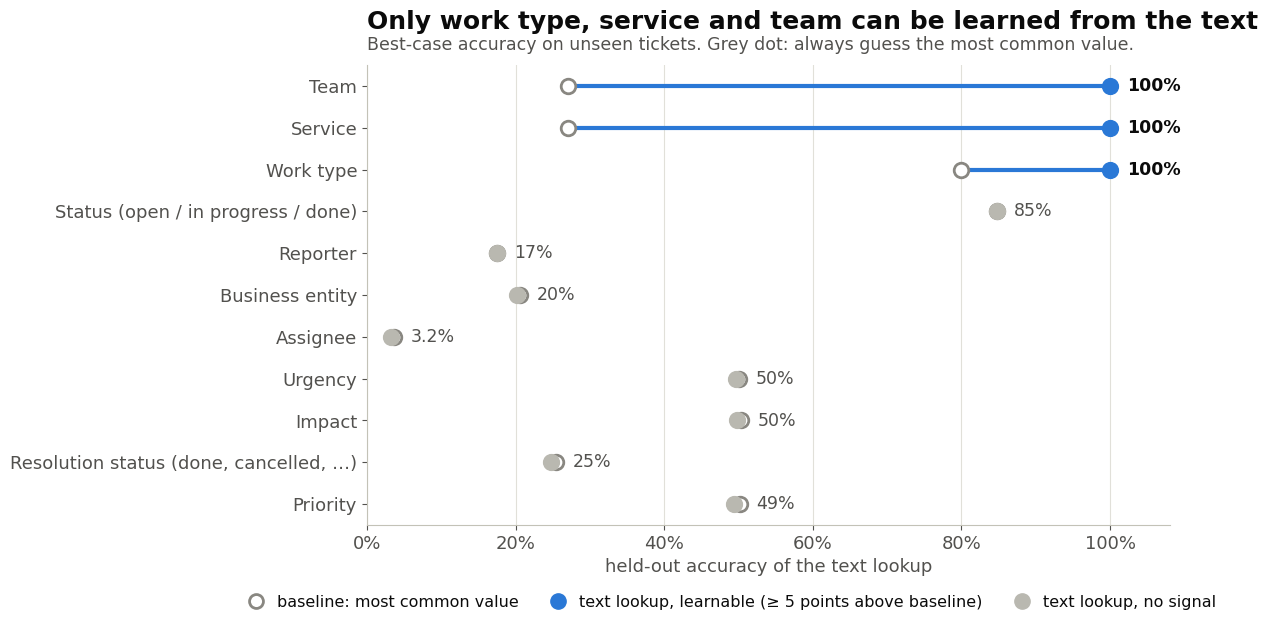

In [14]:
LABELS = {"Status": "Status (open / in progress / done)", "Resolution": "Resolution status (done, cancelled, …)"}

fig, ax = plt.subplots()
pos = np.arange(len(signal))
for y, (field, row) in zip(pos, signal.iterrows()):
    color = ACCENT if row["learnable"] else NOISE
    ax.plot([row["baseline"], row["text lookup"]], [y, y], color=color, lw=3, zorder=1)
    ax.scatter(row["baseline"], y, s=110, color="white", edgecolor=MUTED, lw=2, zorder=2)
    ax.scatter(row["text lookup"], y, s=130, color=color, zorder=3)
    ax.annotate(f"{row['text lookup']:.0%}" if row["text lookup"] >= 0.1 else f"{row['text lookup']:.1%}",
                (max(row["baseline"], row["text lookup"]), y), xytext=(12, 0), textcoords="offset points",
                va="center", fontsize=12.5, fontweight="bold" if row["learnable"] else "normal", color=INK if row["learnable"] else INK_2)
ax.set_yticks(pos, [LABELS.get(f, f) for f in signal.index])
ax.set_xlim(0, 1.08)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("held-out accuracy of the text lookup")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_title("Only work type, service and team can be learned from the text")
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", ms=10, mfc="white", mec=MUTED, mew=2),
                   plt.Line2D([], [], marker="o", ls="", ms=11, color=ACCENT),
                   plt.Line2D([], [], marker="o", ls="", ms=11, color=NOISE)],
          labels=["baseline: most common value", "text lookup, learnable (≥ 5 points above baseline)", "text lookup, no signal"],
          frameon=False, loc="upper center", bbox_to_anchor=(0.45, -0.12), ncol=3, fontsize=11.5, columnspacing=1.5, handletextpad=0.3)
finish(fig, ax, "02_signal_vs_noise", "Best-case accuracy on unseen tickets. Grey dot: always guess the most common value.")

## 3 · Priority does not follow urgency and impact

A real priority matrix would map every (urgency, impact) pair to a priority: low/low to lowest, high/high to high, and so on.

- **Left:** urgency, impact and priority all have the *same* skewed distribution (about 50 / 30 / 10 / 8 / 2 %). That is what three independent random draws from one distribution look like.
- **Right:** average priority level per (urgency, impact) cell, 0 = lowest to 4 = highest. A matrix would give a gradient from the bottom-left to the top-right corner. The cells are flat instead.

Consequence: priority cannot be learned, it is computed by the `PriorityMatrix` from the urgency and impact that the model judges from the text.

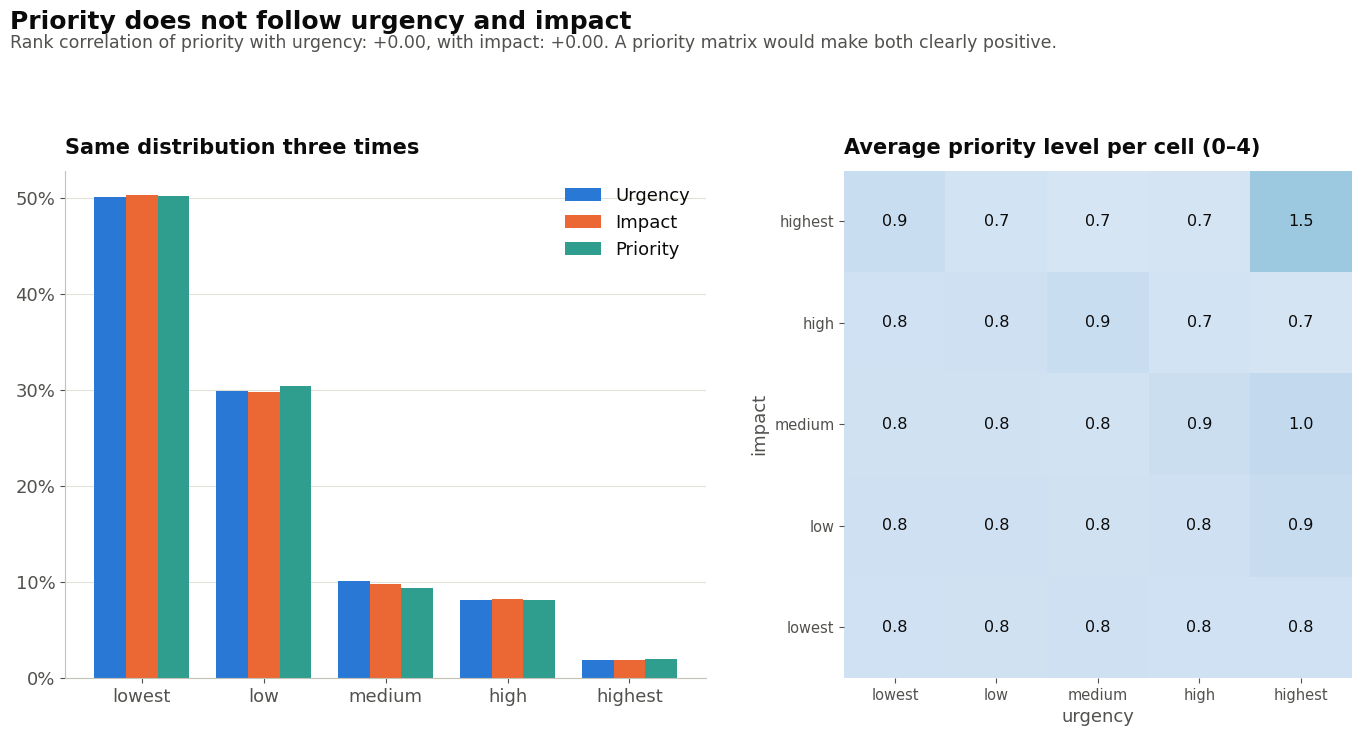

In [15]:
rank = {f: t[f].map(LEVELS) for f in ["Priority", "Urgency", "Impact"]}
rho_u, rho_i = spearmanr(rank["Priority"], rank["Urgency"])[0], spearmanr(rank["Priority"], rank["Impact"])[0]
mean_priority = (pd.DataFrame({"Urgency": t["Urgency"], "Impact": t["Impact"], "p": rank["Priority"]})
                 .pivot_table(index="Impact", columns="Urgency", values="p", aggfunc="mean").reindex(index=LEVEL_NAMES, columns=LEVEL_NAMES))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1.15, 1]})
width = 0.26
for i, (field, color) in enumerate(zip(["Urgency", "Impact", "Priority"], [ACCENT, ACCENT_2, "#2f9e8f"])):
    share = t[field].value_counts(normalize=True).reindex(LEVEL_NAMES)
    ax.bar(np.arange(5) + (i - 1) * width, share.values, width, color=color, label=field)
ax.set_xticks(range(5), LEVEL_NAMES)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False)
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.set_title("Same distribution three times", fontsize=15, pad=12)

im = ax2.imshow(mean_priority.values, cmap="Blues", vmin=0, vmax=4, origin="lower")
ax2.set_xticks(range(5), LEVEL_NAMES, fontsize=10.5)
ax2.set_yticks(range(5), LEVEL_NAMES, fontsize=10.5)
ax2.set_xlabel("urgency")
ax2.set_ylabel("impact")
for (r, c), v in np.ndenumerate(mean_priority.values):
    ax2.text(c, r, f"{v:.1f}", ha="center", va="center", fontsize=11.5, color=INK if v < 2.5 else "white")
ax2.spines[["left", "bottom"]].set_visible(False)
ax2.set_title("Average priority level per cell (0–4)", fontsize=15, pad=12)
finish_panels(fig, "03_priority", "Priority does not follow urgency and impact",
              f"Rank correlation of priority with urgency: {rho_u:+.2f}, with impact: {rho_i:+.2f}. A priority matrix would make both clearly positive.")

## 4 · The resolution status is a coin toss in every template

The resolution status (done, cancelled, clarification, cannot reproduce) exists for the 17,000 resolved tickets. Each bar below is one ticket template. If the status depended on the ticket, the colours would differ from bar to bar. They are the same 25 % in every one, whether the template is an automated alert, an email warning or an access request.

The open / in progress split is tied to the missing resolution date, not to the text.

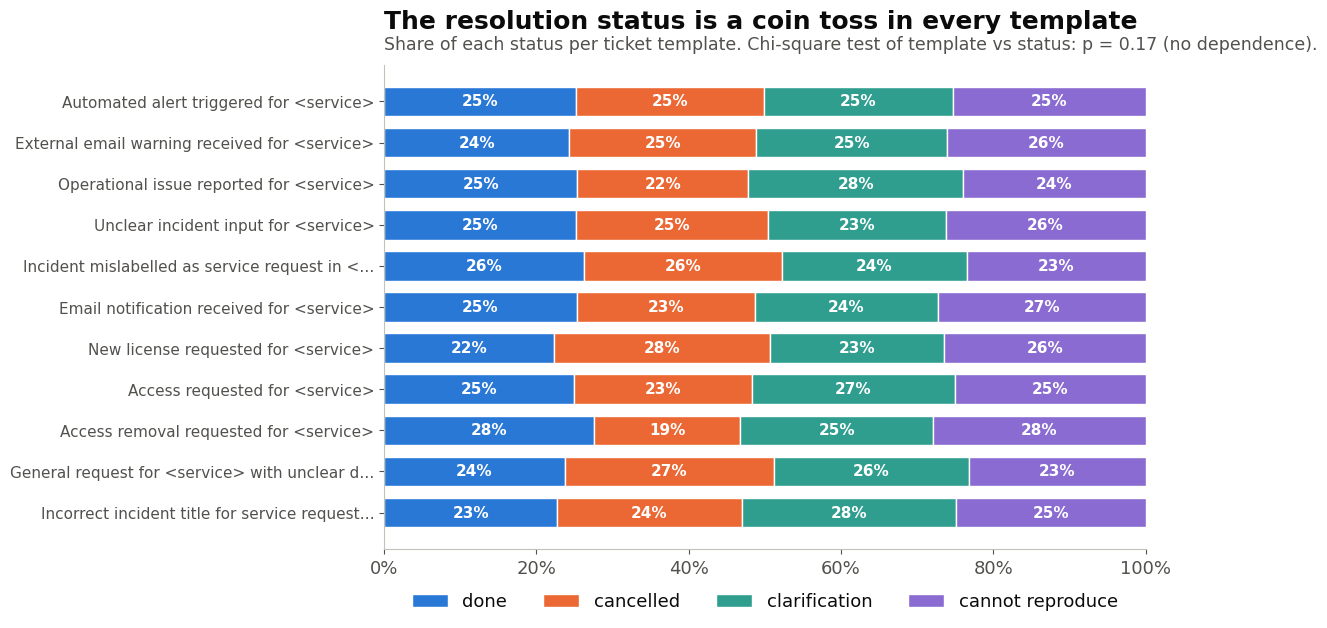

In [16]:
STATUS_ORDER = ["done", "cancelled", "clarification", "cannot reproduce"]
res = t.dropna(subset=["Resolution"])
mix = pd.crosstab(res["Template label"], res["Resolution"], normalize="index")[STATUS_ORDER].loc[by_template.index]
chi2, p_value, _, _ = chi2_contingency(pd.crosstab(res["Template label"], res["Resolution"]))

fig, ax = plt.subplots()
left = np.zeros(len(mix))
for status, color in zip(STATUS_ORDER, CATEGORICAL):
    ax.barh(range(len(mix)), mix[status], left=left, height=0.72, color=color, label=status, edgecolor="white", lw=1)
    for y, (l, v) in enumerate(zip(left, mix[status])):
        ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", color="white", fontsize=11, fontweight="bold")
    left += mix[status].values
ax.set_yticks(range(len(mix)), [l if len(l) <= 46 else l[:44] + "…" for l in mix.index], fontsize=11)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(ncol=4, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.16))
ax.set_title("The resolution status is a coin toss in every template")
finish(fig, ax, "04_resolution", f"Share of each status per ticket template. Chi-square test of template vs status: p = {p_value:.2f} (no dependence).")

## 5 · Resolution time is uniform between 1 and 21 days, unrelated to anything

Real resolution times are skewed: most tickets close quickly, a few take very long. Here the time to resolution is spread evenly over 1 to 21 days (left) and is the same for every priority (right). There is nothing to learn about effort, urgency or complexity.

In [ ]:
days = pd.DataFrame({"days": resolution_days, "Priority": t["Priority"]}).dropna()
by_priority = days.groupby("Priority")["days"].median().reindex(LEVEL_NAMES)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1.3, 1]})
ax.hist(days["days"], bins=np.arange(0, 21.5, 1), color=ACCENT, edgecolor="white")
ax.set_xlabel("days from creation to resolution")
ax.set_ylabel("tickets")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.set_title("Evenly spread", fontsize=15, pad=12)

ax2.bar(range(5), by_priority.values, color=NOISE, width=0.65)
for x, v in enumerate(by_priority.values):
    ax2.text(x, v + 0.2, f"{v:.1f}", ha="center", fontsize=12)
ax2.set_xticks(range(5), LEVEL_NAMES)
ax2.set_ylim(0, 20)
ax2.set_ylabel("median days")
ax2.grid(axis="y")
ax2.set_axisbelow(True)
ax2.set_title("Same for every priority", fontsize=15, pad=12)
finish_panels(fig, "05_resolution_time", "Resolution time carries no information",
              "Only resolved tickets. The lowest and the highest priority take equally long.")

## 6 · The assignee: no field explains who gets a ticket

The assignee is one of 30 people. Each of them appears in every team and every service, with about 1/30 of the tickets. To find out whether *anything* in the export predicts the assignee, every other field is tested against it.

The bar is the **bias-corrected Cramér's V**: 0 = independent, 1 = the field determines the assignee (the axis runs to 1 on purpose). Orange would mark a field that passes the chi-square test after Bonferroni correction for the number of fields tested. No field does.

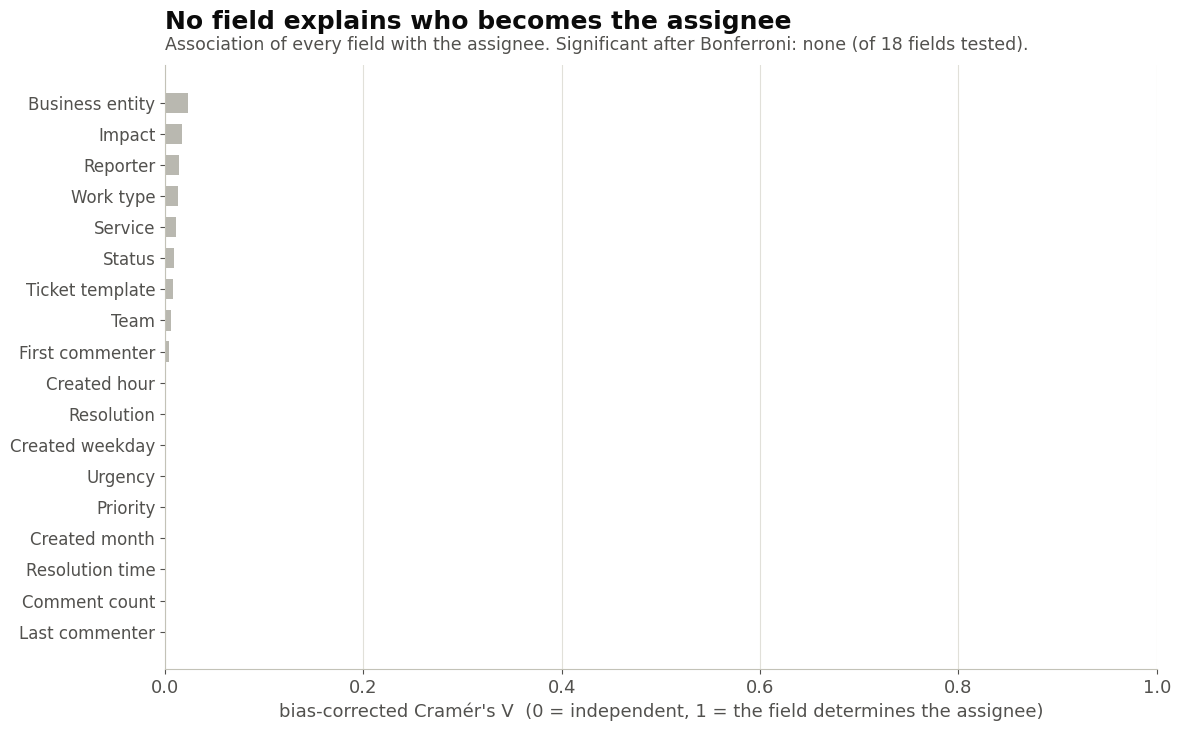

In [17]:
a = t[["Assignee", "Service", "Team", "Business entity", "Work type", "Reporter", "Priority", "Urgency", "Impact",
       "Status", "Resolution", "Template label"]].rename(columns={"Template label": "Ticket template"}).copy()
a["Resolution"] = a["Resolution"].fillna("(unresolved)")
a["Created hour"] = df["Created date"].dt.hour.astype("string")
a["Created weekday"] = df["Created date"].dt.dayofweek.astype("string")
a["Created month"] = df["Created date"].dt.month.astype("string")
a["Resolution time"] = pd.qcut(resolution_days, 5, duplicates="drop").astype("string").fillna("(unresolved)")
a["Comment count"] = df["Comment count"].astype(str)
a["First commenter"] = df["All Comments"].map(lambda c: commenter(c, 0))
a["Last commenter"] = df["All Comments"].map(lambda c: commenter(c, -1))
a["Text"] = t["Text"]
y = a["Assignee"]
FIELDS = [c for c in a.columns if c not in ("Assignee", "Text")]


def cramers_v(x, target):
    table = pd.crosstab(x, target)
    chi2, p, _, _ = chi2_contingency(table, correction=False)
    n = table.values.sum()
    rows, cols = table.shape
    phi2 = max(0.0, chi2 / n - (cols - 1) * (rows - 1) / (n - 1))
    rows_c, cols_c = rows - (rows - 1) ** 2 / (n - 1), cols - (cols - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(1e-12, min(rows_c - 1, cols_c - 1))), p


assoc = pd.DataFrame([(f, *cramers_v(a[f], y)) for f in FIELDS], columns=["Field", "V", "p"]).sort_values("V", ascending=True)
ALPHA = 0.05 / len(FIELDS)
assoc["significant"] = assoc["p"] < ALPHA

fig, ax = plt.subplots(figsize=(12, 7.5))
pos = np.arange(len(assoc))
ax.barh(pos, assoc["V"], height=0.65, color=[ACCENT_2 if s else NOISE for s in assoc["significant"]])
ax.set_yticks(pos, assoc["Field"], fontsize=12)
ax.set_xlim(0, 1)
ax.set_xlabel("bias-corrected Cramér's V  (0 = independent, 1 = the field determines the assignee)")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_title("No field explains who becomes the assignee")
finish(fig, ax, "06_assignee_fields", f"Association of every field with the assignee. Significant after Bonferroni: "
       f"{', '.join(assoc.loc[assoc['significant'], 'Field']) or 'none'} (of {len(FIELDS)} fields tested).")

## 7 · The assignee: every model is at chance level

If a pattern exists, a model should find it. Five models predict the assignee under 5-fold cross-validation, from simple to rich. The dashed lines are chance: 1 of 30 people is 3.3 %, the right person among the top three is 10 %.

| Model | Uses |
|---|---|
| Most common overall | nothing |
| Most common per service | the service (the old routing rule) |
| Logistic regression, routing fields | service, team, entity, work type, reporter |
| Logistic regression, everything | all fields above, dates, comments, resolution and the text |
| **Shuffled-label control** | the same everything-model, but trained on assignees **shuffled** across tickets |

The control shows what "no pattern at all" scores. Real labels do not beat it.

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

N_ASSIGNEES = y.nunique()


class GroupFrequency(BaseEstimator, ClassifierMixin):
    """Predicts the assignee frequencies of the ticket's group. column=None means one group (overall majority)."""

    def __init__(self, column=None):
        self.column = column

    def _keys(self, X):
        return X[self.column] if self.column else pd.Series("all", index=X.index)

    def fit(self, X, y):
        self.classes_ = np.array(sorted(pd.unique(y)))
        table = pd.crosstab(self._keys(X), pd.Series(np.asarray(y), index=X.index)).reindex(columns=self.classes_, fill_value=0)
        self.freq_ = table.div(table.sum(axis=1), axis=0)
        self.prior_ = (table.sum() / table.values.sum()).to_numpy()
        return self

    def predict_proba(self, X):
        return self.freq_.reindex(self._keys(X)).fillna(pd.Series(self.prior_, index=self.classes_)).to_numpy()

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


ROUTING = ["Service", "Team", "Business entity", "Work type", "Reporter"]
routing_lr = make_pipeline(ColumnTransformer([("c", OneHotEncoder(handle_unknown="ignore", min_frequency=5), ROUTING)]),
                           LogisticRegression(C=0.05, max_iter=300))
everything_lr = make_pipeline(ColumnTransformer([
    ("c", OneHotEncoder(handle_unknown="ignore", min_frequency=5), FIELDS),
    ("t", TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True), "Text"),
]), LogisticRegression(C=0.05, max_iter=300))

MODELS = {
    "Most common\noverall": GroupFrequency(),
    "Most common\nper service": GroupFrequency("Service"),
    "Logistic regression\nrouting fields": routing_lr,
    "Logistic regression\neverything": everything_lr,
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
classes = np.array(sorted(y.unique()))


def top_k(proba, truth, k):
    best = np.argsort(-proba, axis=1)[:, :k]
    return float(np.mean([t_ in set(classes[row]) for t_, row in zip(truth, best)]))


rows = []
for name, model in MODELS.items():
    proba = cross_val_predict(model, a, y, cv=cv, method="predict_proba", n_jobs=-1)
    rows.append({"Model": name, "top-1": top_k(proba, y.to_numpy(), 1), "top-3": top_k(proba, y.to_numpy(), 3)})

# Control: the same model on shuffled assignees. This is what "no pattern" scores.
rng = np.random.default_rng(SEED)
control = []
for _ in range(3):
    shuffled = pd.Series(rng.permutation(y.to_numpy()), index=y.index)
    proba = cross_val_predict(everything_lr, a, shuffled, cv=cv, method="predict_proba", n_jobs=-1)
    control.append((top_k(proba, shuffled.to_numpy(), 1), top_k(proba, shuffled.to_numpy(), 3)))
rows.append({"Model": "Shuffled-label\ncontrol", "top-1": np.mean([c[0] for c in control]), "top-3": np.mean([c[1] for c in control])})

scores = pd.DataFrame(rows).set_index("Model")
scores.style.format("{:.2%}")

In [ ]:
fig, ax = plt.subplots()
x = np.arange(len(scores))
w = 0.38
ax.bar(x - w / 2, scores["top-1"], w, color=ACCENT, label="top-1: the suggested person is right")
ax.bar(x + w / 2, scores["top-3"], w, color=ACCENT_2, label="top-3: the right person is among three")
ax.axhline(1 / N_ASSIGNEES, color=ACCENT, ls="--", lw=1.5, label="chance for top-1: 3.3 %")
ax.axhline(3 / N_ASSIGNEES, color=ACCENT_2, ls="--", lw=1.5, label="chance for top-3: 10 %")
for xi, (t1, t3) in enumerate(zip(scores["top-1"], scores["top-3"])):
    ax.annotate(f"{t1:.1%}", (xi - w / 2, t1), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=12)
    ax.annotate(f"{t3:.1%}", (xi + w / 2, t3), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=12)
ax.set_xticks(x, scores.index)
ax.set_ylim(0, 0.16)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False, loc="upper left", fontsize=12, ncol=2)
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.set_title("Every model is at chance level")
finish(fig, ax, "07_assignee_models", "Predicting the assignee out of 30 people, 5-fold cross-validation. The richest model does not beat shuffled labels.")

## Summary: what the training data is good for

| Output field | Learnable from the data? | Why | What the pipeline does instead |
|---|---|---|---|
| Work type | Yes, trivially | Determined by the ticket template | LLM classifies from the text |
| Affected service | Yes, trivially | The service name is in the text | LLM picks it, validated against the service catalogue |
| Service team | Yes, trivially | Team follows the service 1:1 | Majority vote per service from the history |
| **Priority** | **No** | Independent draws, no link to urgency and impact | Computed by the `PriorityMatrix` from urgency and impact |
| Urgency, impact | No | Random, same distribution as priority | LLM judges them from the text, never from the history |
| **Resolution status** | **No** | 25 % per class in every template | LLM decides from the meaning of the text |
| Resolution comment | Only as wording | 21 distinct resolution texts, unrelated to the ticket | LLM drafts from the text and similar tickets |
| **Assignee** | **No** | No field, order or model beats 1 / 30 | Person with the fewest tickets (even workload) |

**What remains useful:** the history as a set of *similar tickets* (retrieval) and as the service-to-team table. It is **not** useful as training or evaluation data for priority, urgency, impact, resolution status or assignee: any accuracy on them is chance, whatever the model. Expect the scoring on those fields to be near chance for every team, and put the effort into the fields where the text carries the answer.

## Appendix: raw overview

In [ ]:
def first(values):
    # Every ticket has exactly one value per list field.
    return values[0] if isinstance(values, list) and values else "(none)"


def commenter(comments, position):
    return comments[position].split(":")[0] if isinstance(comments, list) and comments else "(none)"


t = pd.DataFrame(index=df.index)
t["Work type"] = df["Work type"]
t["Service"] = df["Affected Business or IT Services"].map(first)
t["Team"] = df["Service Team(s)"].map(first)
t["Business entity"] = df["Business Entity"].map(first)
t["Reporter"] = df["Reporter"]
t["Assignee"] = df["Assignee"]
for col in ["Priority", "Urgency", "Impact", "Status", "Resolution"]:
    t[col] = df[col]
t["Text"] = df["Summary"] + "\n" + df["Description"]

# The ticket texts are templates with a service name filled in. Removing the names shows the template.
names = sorted(t["Service"].unique(), key=len, reverse=True)
NAME_RE = re.compile("|".join(map(re.escape, names)))
t["Template"] = df["Description"].map(lambda d: NAME_RE.sub("<service>", d))
summary_pattern = df["Summary"].map(lambda s: NAME_RE.sub("<service>", s))
label_of = summary_pattern.groupby(t["Template"]).agg(lambda s: s.value_counts().index[0])
t["Template label"] = t["Template"].map(label_of)

LEVELS = {"lowest": 0, "low": 1, "medium": 2, "high": 3, "highest": 4}
LEVEL_NAMES = list(LEVELS)
resolution_days = (df["Resolution date"] - df["Created date"]).dt.total_seconds() / 86400

print(f"{t['Text'].nunique()} distinct texts, {t['Template'].nunique()} templates, {t['Service'].nunique()} services, "
      f"{t['Assignee'].nunique()} assignees, {t['Reporter'].nunique()} reporters")

In [ ]:
by_template = t.groupby("Template label").agg(tickets=("Text", "size"), work_type=("Work type", lambda s: s.value_counts().index[0]),
                                              purity=("Work type", lambda s: s.value_counts(normalize=True).iloc[0])).sort_values("tickets")
colors = [ACCENT if w == "Incident" else ACCENT_2 for w in by_template["work_type"]]

fig, ax = plt.subplots()
pos = np.arange(len(by_template))
ax.barh(pos, by_template["tickets"], height=0.7, color=colors)
for y, n in zip(pos, by_template["tickets"]):
    ax.annotate(f"{n:,}", (n, y), xytext=(6, 0), textcoords="offset points", va="center", color=INK_2, fontsize=12)
ax.set_yticks(pos, [l if len(l) <= 46 else l[:44] + "…" for l in by_template.index], fontsize=11)
ax.set_xlim(0, by_template["tickets"].max() * 1.12)
ax.set_xlabel("tickets")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_title("20,000 tickets are just 11 texts × 20 services")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=ACCENT), plt.Rectangle((0, 0), 1, 1, color=ACCENT_2)],
          labels=["Incident", "Service Request"], frameon=False, loc="lower right")
finish(fig, ax, "01_templates", f"{t['Text'].nunique()} distinct texts in total. The work type is determined by the template in "
       f"{(by_template['purity'] * by_template['tickets']).sum() / len(t):.0%} of the tickets.")

In [ ]:
from sklearn.model_selection import KFold


def text_lookup_accuracy(target):
    """Held-out accuracy of 'most common value per exact text' and of 'most common value overall'."""
    d = pd.DataFrame({"text": t["Text"], "y": t[target]}).dropna()
    correct = 0
    for train_idx, test_idx in KFold(5, shuffle=True, random_state=SEED).split(d):
        train, test = d.iloc[train_idx], d.iloc[test_idx]
        best = train.groupby("text")["y"].agg(lambda s: s.value_counts().index[0])
        fallback = train["y"].value_counts().index[0]
        correct += (test["text"].map(best).fillna(fallback) == test["y"]).sum()
    return correct / len(d), d["y"].value_counts(normalize=True).iloc[0]


TARGETS = ["Work type", "Service", "Team", "Business entity", "Reporter", "Assignee",
           "Priority", "Urgency", "Impact", "Status", "Resolution"]
signal = pd.DataFrame([(f, *text_lookup_accuracy(f)) for f in TARGETS], columns=["Field", "text lookup", "baseline"]).set_index("Field")
signal["lift"] = signal["text lookup"] - signal["baseline"]
signal["learnable"] = signal["lift"] >= 0.05
signal = signal.sort_values(["learnable", "lift"], ascending=[True, True])
signal.style.format("{:.1%}", subset=["text lookup", "baseline", "lift"])